# Lecture 04 — Inventory ordering with Q-learning

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Reinforcement learning (tabular Q-learning) · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Learn replenishment decisions under random demand.

## Practical problem
A simple shop has stock levels 0–10, can order 0, 2 or 4 units, and experiences random demand of 0–3 units.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** The demand model is uniform and rewards are fabricated; this is a teaching demonstration, not a production stock policy.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 132 rows × 6 columns


,stock,order_units,demand_units,demand_probability,next_stock,reward
0,0,0,0,0.25,0,0.0
1,0,0,1,0.25,0,-2.5
2,0,0,2,0.25,0,-5.0
3,0,0,3,0.25,0,-7.5
4,0,2,0,0.25,2,-4.2


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['stock', 'order_units', 'demand_units', 'demand_probability', 'next_stock', 'reward']
Missing values per column:
stock                 0
order_units           0
demand_units          0
demand_probability    0
next_stock            0
reward                0


## 2. Define states, actions, rewards and transitions
An RL agent learns by taking actions and receiving rewards. Here `dataset.csv` describes a **simulated environment**, not a labelled set of optimal actions. This is a tabular Q-learning demonstration.

order_units,0,2,4
stock,,,
0,-3.75,3.42,1.5
1,2.48,5.10,0.9
2,6.42,4.50,0.3
3,8.10,3.90,-0.3
4,7.50,3.30,-0.9


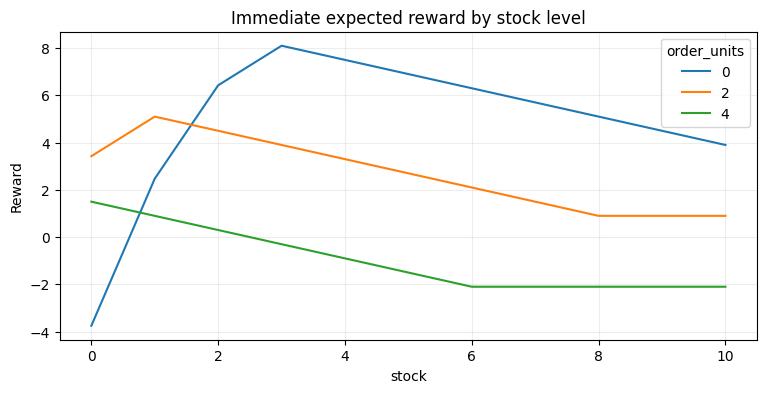

In [3]:
orders=[0,2,4];transition={(int(r.stock),int(r.order_units),int(r.demand_units)):(int(r.next_stock),float(r.reward)) for r in df.itertuples()}
summary=df.groupby(['stock','order_units'])['reward'].mean().unstack()
display(summary.head().round(2))
summary.plot(figsize=(9,4),title='Immediate expected reward by stock level',ylabel='Reward');plt.show()

## 3. Train by exploring the environment
Q-learning updates an action value toward `reward + γ × best future Q`. Exploration (ε-greedy) helps an agent learn rather than repeating an initially arbitrary action.

In [4]:
rng=np.random.default_rng(11);Q=np.zeros((11,3));alpha=.18;gamma=.92;eps=.18
returns=[]
for ep in range(2400):
 state=int(rng.integers(0,11));total=0
 for t in range(30):
  ai=int(rng.integers(0,3)) if rng.random()<eps else int(np.argmax(Q[state]))
  demand=int(rng.integers(0,4));nxt,r=transition[(state,orders[ai],demand)]
  Q[state,ai]+=alpha*(r+gamma*np.max(Q[nxt])-Q[state,ai])
  state=nxt;total+=r
 returns.append(total)
print('Best order size by stock level:',{stock:orders[int(np.argmax(Q[stock]))] for stock in range(11)})

Best order size by stock level: {0: 4, 1: 2, 2: 0, 3: 2, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 2, 10: 0}


## 4. Evaluate the learned policy
RL evaluation focuses on **episode return, task success rate or operational reward**, not a confusion matrix. There are no supervised target classes in these examples.

In [5]:
def simulate_policy(start=4,steps=20,seed=999):
 rr=np.random.default_rng(seed);stock=start;route=[stock];actions=[];rewards=[]
 for t in range(steps):
  order=orders[int(np.argmax(Q[stock]))];demand=int(rr.integers(0,4));nxt,r=transition[(stock,order,demand)]
  actions.append(order);rewards.append(r);route.append(nxt);stock=nxt
 return route,actions,rewards
stocks,orders_used,rs=simulate_policy()
print('20-step average reward:',round(np.mean(rs),2),'Total reward:',round(sum(rs),2))
print('Orders:',orders_used)

20-step average reward: 3.92 Total reward: 78.4
Orders: [0, 2, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 2, 2, 0, 0, 4, 0, 4, 0]


## 5. Visualise what was learned

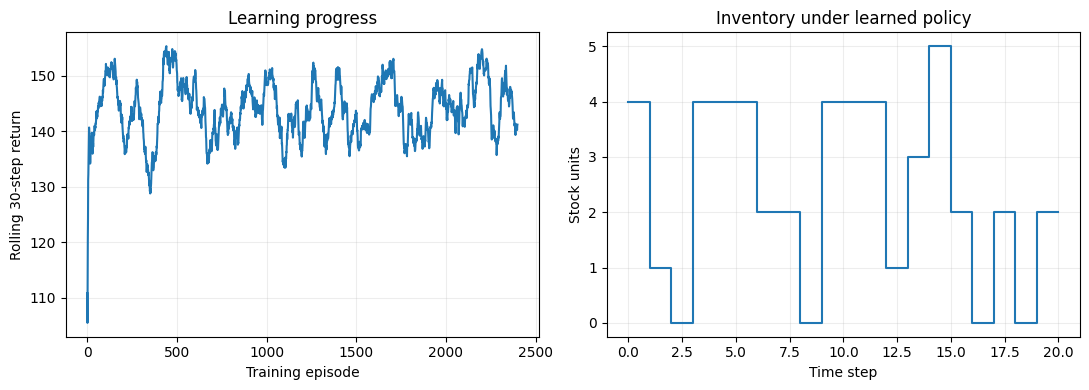

In [6]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(pd.Series(returns).rolling(75,min_periods=1).mean());ax[0].set(xlabel='Training episode',ylabel='Rolling 30-step return',title='Learning progress')
ax[1].step(range(len(stocks)),stocks,where='post');ax[1].set(xlabel='Time step',ylabel='Stock units',title='Inventory under learned policy')
plt.tight_layout();plt.show()

## 6. Apply the learned policy to new starting conditions

In [7]:
for start in [0,2,5,9]:
 stocks,orders_used,rs=simulate_policy(start=start,steps=12,seed=101)
 print(f'Start={start}, first order={orders_used[0]}, mean reward={np.mean(rs):.2f}, ending stock={stocks[-1]}')

Start=0, first order=4, mean reward=6.45, ending stock=0
Start=2, first order=0, mean reward=7.00, ending stock=0
Start=5, first order=0, mean reward=5.89, ending stock=2
Start=9, first order=2, mean reward=5.94, ending stock=0


## Student investigation and discussion
1. What is the cost of ordering too much stock?
2. Would changing the demand distribution change the best policy?
3. How is this different from forecasting the next sales figure with regression?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.